<a href="https://colab.research.google.com/github/kaurarman/DS/blob/main/datascience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("loan_approval_dataset.csv")

In [2]:
df.columns = df.columns.str.strip()

In [3]:
print(df.isnull().sum())

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [4]:
print(df.duplicated().sum())

0


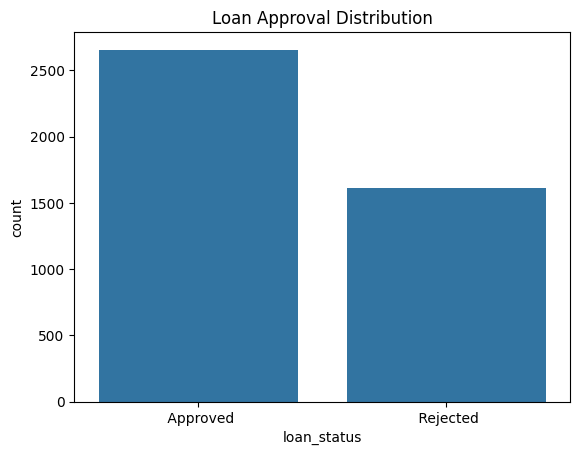

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

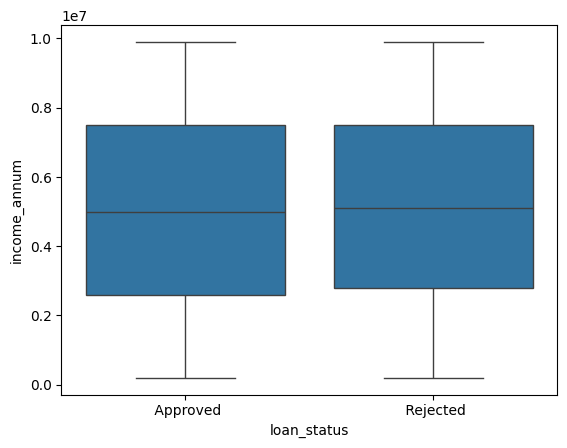

In [6]:
sns.boxplot(
    x='loan_status',
    y='income_annum',
    data=df
)
plt.show()

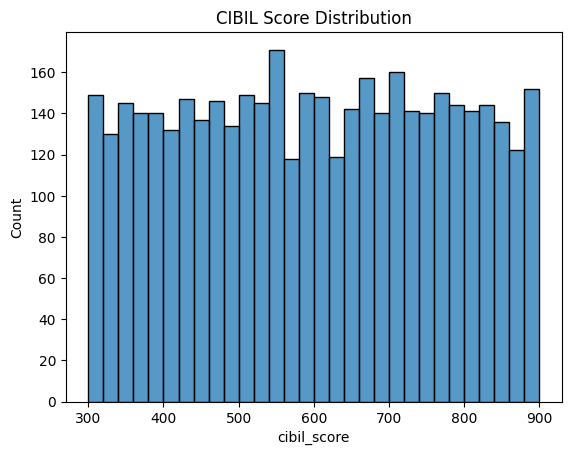

In [7]:
sns.histplot(df['cibil_score'], bins=30)
plt.title("CIBIL Score Distribution")
plt.show()

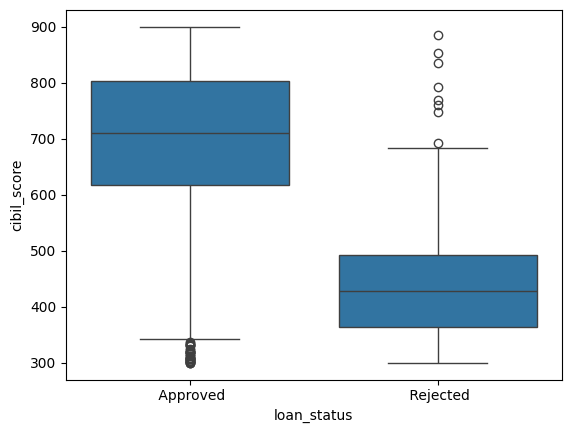

In [8]:
sns.boxplot(
    x='loan_status',
    y='cibil_score',
    data=df
)
plt.show()

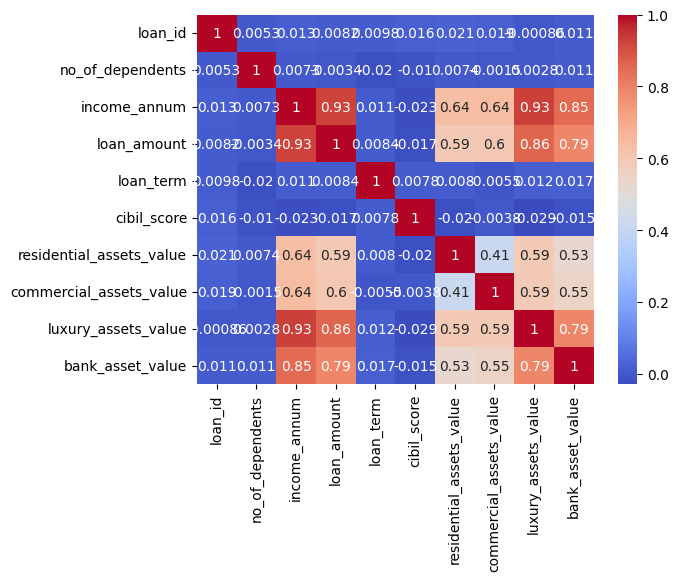

In [9]:
numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])

In [11]:
X = df.drop(
    ['loan_status', 'loan_id'],
    axis=1
)

y = df['loan_status']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7985948477751756


In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print(
    accuracy_score(y_test, pred)
)

0.977751756440281


In [17]:
import joblib

joblib.dump(rf, "credit_risk_model.pkl")

['credit_risk_model.pkl']